In [1]:
"""
=============================================================================
PIPELINE EDA & PREPROCESSING — KLASIFIKASI BAHAYA INDUSTRI BERBASIS LLM
=============================================================================
Thesis : Evaluasi Komparatif Metode Klasifikasi Pendekatan LLM
         pada Data Keselamatan Industri
Penulis: Riza Rahmah Angelia | NRP: M0501241008 | IPB University
=============================================================================
 
ALUR EKSEKUSI (satu file, satu df, tanpa file perantara):
  TAHAP 0 → Import Library & Konfigurasi
  TAHAP 1 → Load Data & Inspeksi Awal
  TAHAP 2 → Analisis Distribusi Kelas (Class Imbalance)
  TAHAP 3 → Analisis Linguistik Teks (EDA pada teks_gabungan)
  TAHAP 4 → Preprocessing Final (teks_final: [DESKRIPSI] + [LOKASI])
  TAHAP 5 → QA: Verifikasi Hasil Preprocessing
  TAHAP 6 → Embedding & Visualisasi t-SNE (Semantic Overlap)
  TAHAP 7 → Deduplikasi & Stratified Split (KB 90% / Test 10%)
  TAHAP 8 → Ekspor Output Final
 
KEPUTUSAN DESAIN (hasil diskusi metodologi):
  ✔  Kolom input  : Deskripsi + merge(Lokasi, Detail Lokasi)
  ✗  Dikecualikan : Ketidaksesuaian, Sub Ketidaksesuaian → risiko label leakage
  ✔  Separator    : "[DESKRIPSI]: ... [LOKASI]: ..."  → LLM tahu batas field
  ✔  Hapus        : ID numerik di awal (tasklist_eval / 6-9 digit angka)
  ✔  Pertahankan  : Kode site prefix (B8), (PAMA), dst → informasi konteks
  ✗  TIDAK hapus  : stopword, stemming, case folding, jargon teknis
 
INSTALASI:
=============================================================================
"""
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install sentence-transformers openpyxl packaging

In [2]:
# =============================================================================
# TAHAP 0: IMPORT LIBRARY & KONFIGURASI
# =============================================================================
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
 
warnings.filterwarnings("ignore")
 
# ── Style global matplotlib ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor"  : "#f8f9fa",
    "axes.grid"       : True,
    "grid.alpha"      : 0.4,
    "font.family"     : "sans-serif",
    "font.size"       : 11,
})
 
# ── Konfigurasi path & parameter ──
FILE_PATH    = "Dataset_Thesis4.xlsx"   # File sumber (lokal)
OUTPUT_DIR   = "."                       # Folder output plot & CSV
RANDOM_SEED  = 42
TEST_SIZE    = 0.10                      # 10% untuk test set
 
# ── Definisi kolom ──
COL_ID      = "tasklist_eval"
COL_DESC    = "Deskripsi"
COL_LOC     = "Lokasi"
COL_LOC_DET = "Detail Lokasi"
COL_LABEL   = "Kategori"
 
# Kolom 6 (untuk EDA linguistik awal) — TIDAK dipakai sebagai input LLM
# karena Ketidaksesuaian & Sub Ketidaksesuaian mengandung risiko label leakage
COL_EDA_SIX = [COL_ID, COL_DESC, "Ketidaksesuaian", "Sub Ketidaksesuaian",
               COL_LOC, COL_LOC_DET]
 
# Kolom yang dipakai sebagai input LLM (final)
COL_INPUT   = [COL_DESC, COL_LOC, COL_LOC_DET]
 
# Kolom final yang diekspor
COL_FINAL   = "teks_final"
COL_MERGED  = "lokasi_merged"
 
# Model embedding untuk t-SNE
EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"


In [3]:
# =============================================================================
# TAHAP 1: LOAD DATA & INSPEKSI AWAL
# =============================================================================
print("TAHAP 1: LOAD DATA & INSPEKSI AWAL")
 
df = pd.read_excel(FILE_PATH)
n_raw = len(df)
 
print(f"\n✔ Data dimuat dari: {FILE_PATH}")
print(f"  Shape raw       : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\n  Kolom tersedia ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"    {i:>2}. {col}")
 
print(f"\n── Tipe Data & Missing Values ──")
info = pd.DataFrame({
    "dtype"   : df.dtypes,
    "n_null"  : df.isnull().sum(),
    "pct_null": (df.isnull().sum() / len(df) * 100).round(2),
})
print(info.to_string())
 
# Validasi kolom wajib ada
required_cols = [COL_DESC, COL_LOC, COL_LOC_DET, COL_LABEL, COL_ID]
missing_req = [c for c in required_cols if c not in df.columns]
if missing_req:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_req}")
 
# Drop baris tanpa label atau deskripsi (minimum requirement)
before = len(df)
df = df.dropna(subset=[COL_LABEL, COL_DESC]).reset_index(drop=True)
print(f"\n✔ Drop baris tanpa label/deskripsi: {before} → {len(df)} baris")
 
# Normalisasi label: strip whitespace
df[COL_LABEL] = df[COL_LABEL].astype(str).str.strip()
 
print(f"\n── Sampel 3 baris pertama ──")
print(df[[COL_ID, COL_DESC, COL_LOC, COL_LOC_DET, COL_LABEL]].head(3).to_string())

TAHAP 1: LOAD DATA & INSPEKSI AWAL

✔ Data dimuat dari: Dataset_Thesis4.xlsx
  Shape raw       : 704 baris × 7 kolom

  Kolom tersedia (7):
     1. tasklist_eval
     2. Deskripsi
     3. Ketidaksesuaian
     4. Sub Ketidaksesuaian
     5. Lokasi
     6. Detail Lokasi
     7. Kategori

── Tipe Data & Missing Values ──
                      dtype  n_null  pct_null
tasklist_eval         int64       0      0.00
Deskripsi            object       0      0.00
Ketidaksesuaian      object       0      0.00
Sub Ketidaksesuaian  object       0      0.00
Lokasi               object      32      4.55
Detail Lokasi        object      32      4.55
Kategori             object       0      0.00

✔ Drop baris tanpa label/deskripsi: 704 → 704 baris

── Sampel 3 baris pertama ──
   tasklist_eval                   Deskripsi      Lokasi     Detail Lokasi Kategori
0        8237826               Paritan buntu   Mess Pama  Mess Guest House  Non TBC
1        8237130  Label fire alarm tidak ada  Towing Tug     

TAHAP 2: ANALISIS DISTRIBUSI KELAS

Distribusi Kelas:
                                                    Kategori  Jumlah  Persentase (%)
                                                     Non TBC     597           84.80
                                  5. Deviasi Loading/Dumping      43            6.11
4. Posisi Pekerja pada Area Tidak aman/Tidak Sesuai Prosedur      16            2.27
                                              14. Technology      11            1.56
                                       11. Bahaya Elektrikal       5            0.71
                               13. Aktivitas Drill and Blast       5            0.71
                                         12. Bahaya Biologis       5            0.71
           6. Tidak terdapat pengawas/pengawas tidak memadai       4            0.57
     10. Tools Tidak Standard / Penggunaan Tools Tidak Tepat       3            0.43
                                   2. Deviasi penggunaan APD       3            0.43
           

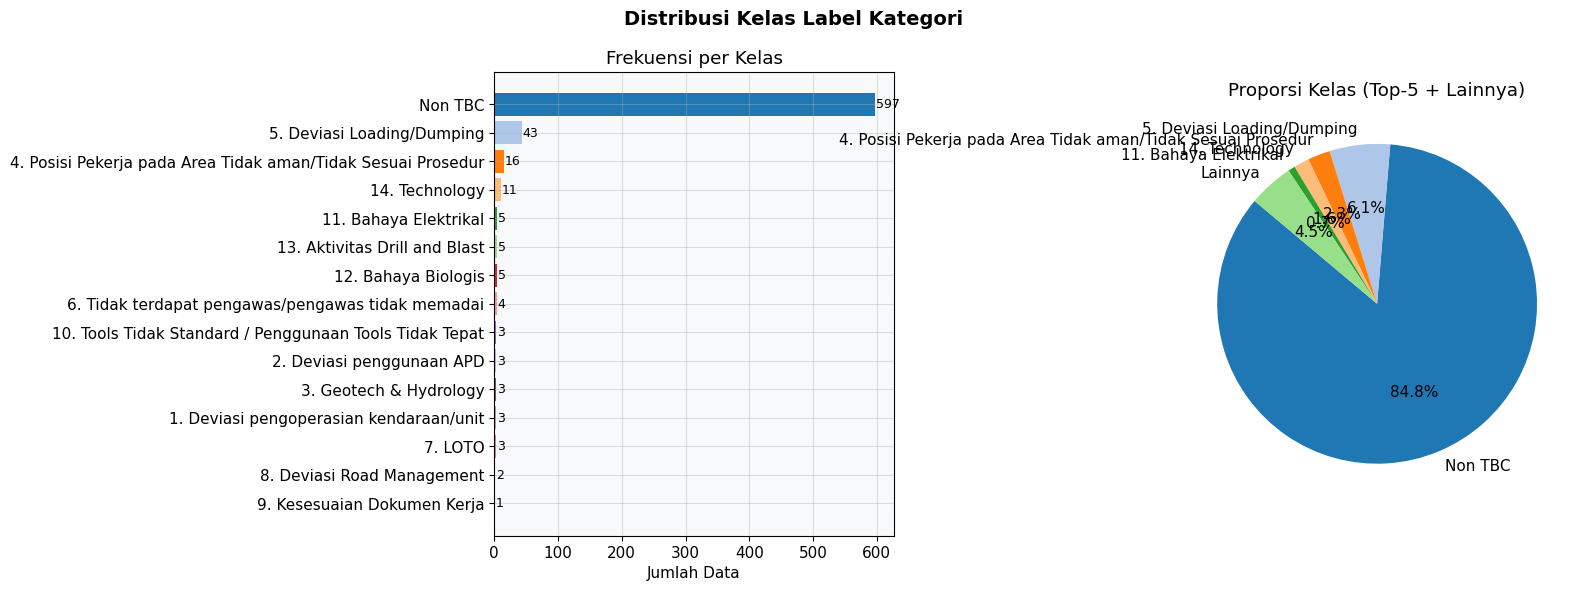

✔ Plot disimpan: 01_distribusi_kelas.png


In [4]:
# =============================================================================
# TAHAP 2: ANALISIS DISTRIBUSI KELAS
# =============================================================================
print("TAHAP 2: ANALISIS DISTRIBUSI KELAS")
 
class_counts = df[COL_LABEL].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)
ir           = class_counts.max() / class_counts.min()
n_class      = len(class_counts)
 
dist_df = pd.DataFrame({
    "Kategori"      : class_counts.index,
    "Jumlah"        : class_counts.values,
    "Persentase (%)": class_pct.values,
})
print("\nDistribusi Kelas:")
print(dist_df.to_string(index=False))
print(f"\n  Imbalance Ratio (IR) : {ir:.2f}x")
print(f"  Kelas Mayoritas      : {class_counts.idxmax()} ({class_pct.max()}%)")
print(f"  Kelas Minoritas      : {class_counts.idxmin()} ({class_pct.min()}%)")
print(f"  Total kelas          : {n_class}")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribusi Kelas Label Kategori", fontsize=14, fontweight="bold")
 
colors = sns.color_palette("tab20", len(class_counts))
axes[0].barh(class_counts.index[::-1], class_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Jumlah Data")
axes[0].set_title("Frekuensi per Kelas")
for i, v in enumerate(class_counts.values[::-1]):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)
 
top5      = class_counts.head(5)
other_sum = class_counts.iloc[5:].sum()
pie_data   = list(top5.values) + ([other_sum] if other_sum > 0 else [])
pie_labels = list(top5.index)  + (["Lainnya"]  if other_sum > 0 else [])
axes[1].pie(pie_data, labels=pie_labels, autopct="%1.1f%%",
            colors=colors[:len(pie_data)], startangle=140)
axes[1].set_title("Proporsi Kelas (Top-5 + Lainnya)")
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_distribusi_kelas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 01_distribusi_kelas.png")
 

TAHAP 3: ANALISIS LINGUISTIK TEKS

Catatan: EDA linguistik dilakukan pada gabungan 6 kolom untuk memahami
karakteristik teks secara menyeluruh. Kolom 'Ketidaksesuaian' dan
'Sub Ketidaksesuaian' HANYA dipakai di tahap EDA ini — tidak masuk
ke pipeline preprocessing LLM (risiko label leakage).


Statistik Panjang Teks - gabungan 6 kolom (karakter):
count    704.0
mean     144.1
std       44.1
min       96.0
25%      118.0
50%      135.0
75%      159.2
max      781.0

Statistik Jumlah Kata:
count    704.0
mean      24.7
std        6.4
min       16.0
25%       21.0
50%       24.0
75%       27.0
max      121.0

Statistik Jumlah Kalimat (estimasi via [.!?]):
count    704.0
mean       0.1
std        0.4
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        6.0


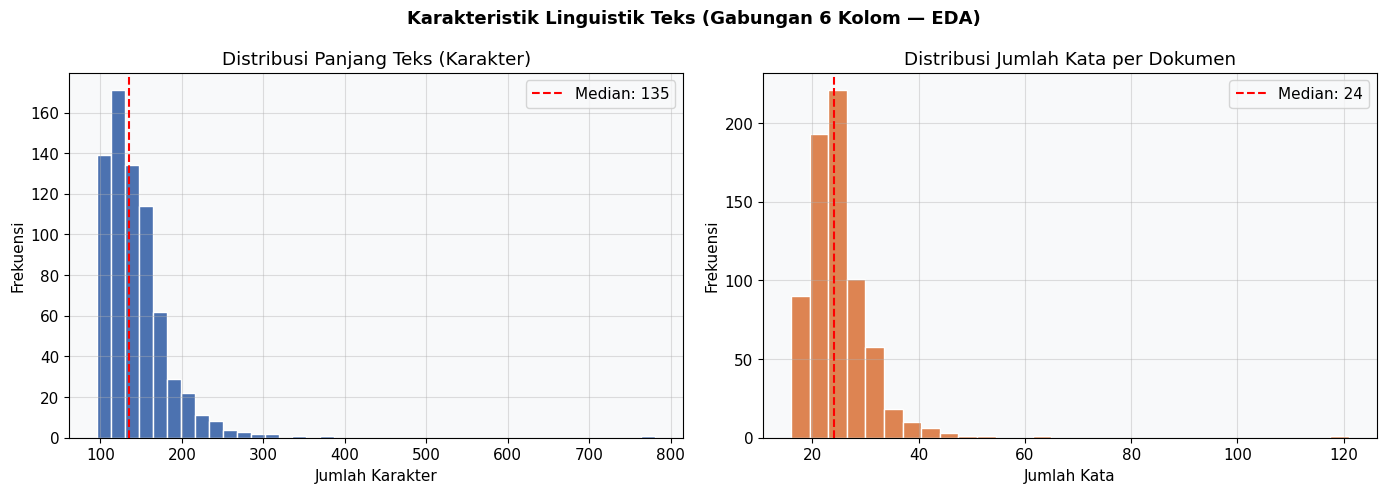

✔ Plot disimpan: 02_distribusi_panjang_teks_eda.png

── Analisis Noise Linguistik ──
URL terdeteksi                    0
Karakter spesial non-standar    704
Mengandung angka                704
Kapital beruntun (AKRONIM)      568
Hashtag (#tag)                    8
ID numerik di awal teks         704

  Teks terlalu pendek (≤ 3 karakter) : 0 baris  → tidak ada

Top 30 kata paling sering (sebelum preprocessing):
      Kata  Frekuensi
         |       3456
     tidak        443
        di        293
     jalan        288
     belum        177
       pit        164
  disposal        152
      area        147
   dumping        147
  workshop        138
    sampah        126
       tug        120
     front        119
        tb        117
    towing        115
    bahaya        111
      (b8)        110
     rambu        108
   pekerja        106
      pada        104
     kerja        104
      pama         95
undulating         93
       kdc         93
        (b         92
      pmo)    

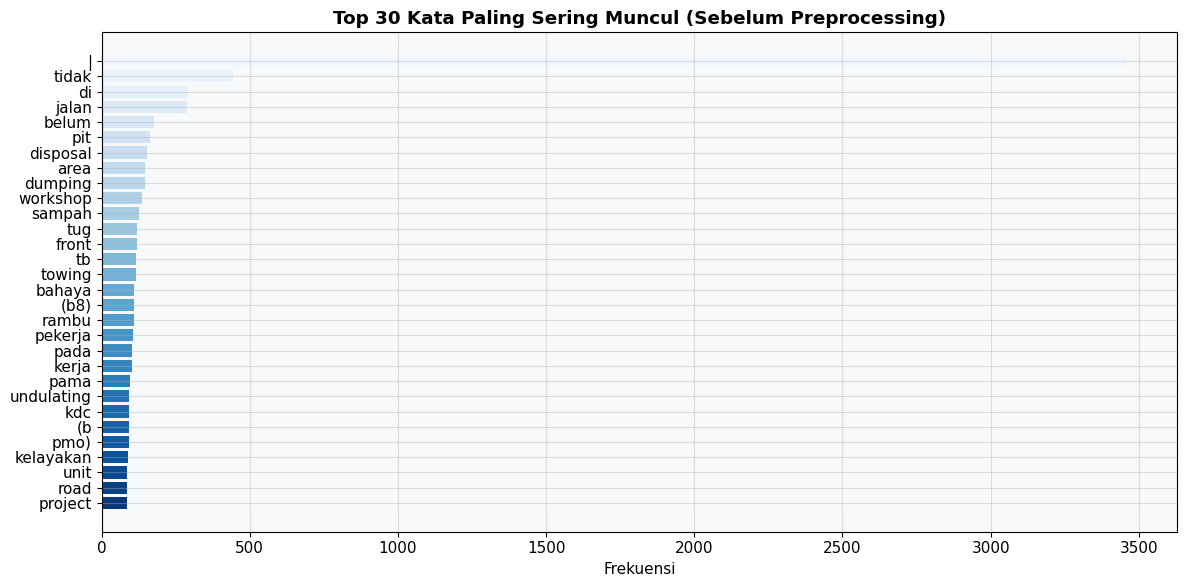

✔ Plot disimpan: 03_frekuensi_kata_eda.png


In [5]:
# =============================================================================
# TAHAP 3: ANALISIS LINGUISTIK TEKS (EDA pada gabungan 6 kolom)
# =============================================================================
print("TAHAP 3: ANALISIS LINGUISTIK TEKS")

print("""
Catatan: EDA linguistik dilakukan pada gabungan 6 kolom untuk memahami
karakteristik teks secara menyeluruh. Kolom 'Ketidaksesuaian' dan
'Sub Ketidaksesuaian' HANYA dipakai di tahap EDA ini — tidak masuk
ke pipeline preprocessing LLM (risiko label leakage).
""")
 
# Buat gabungan 6 kolom hanya untuk keperluan EDA (tidak disimpan ke output)
eda_cols_available = [c for c in COL_EDA_SIX if c in df.columns]
teks_eda = df[eda_cols_available].apply(
    lambda row: " | ".join(row.dropna().astype(str).tolist()), axis=1
)
 
# ── 3a. Statistik panjang teks ──
n_char     = teks_eda.str.len()
n_word     = teks_eda.str.split().str.len()
n_sentence = teks_eda.str.count(r"[.!?]+")   # jumlah kalimat per dokumen
 
print(f"\nStatistik Panjang Teks - gabungan {len(eda_cols_available)} kolom (karakter):")
print(n_char.describe().round(1).to_string())
print(f"\nStatistik Jumlah Kata:")
print(n_word.describe().round(1).to_string())
print(f"\nStatistik Jumlah Kalimat (estimasi via [.!?]):")
print(n_sentence.describe().round(1).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Karakteristik Linguistik Teks (Gabungan {len(eda_cols_available)} Kolom — EDA)",
             fontsize=13, fontweight="bold")
axes[0].hist(n_char, bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(n_char.median(), color="red", linestyle="--",
                label=f"Median: {n_char.median():.0f}")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Panjang Teks (Karakter)")
axes[0].legend()
axes[1].hist(n_word, bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(n_word.median(), color="red", linestyle="--",
                label=f"Median: {n_word.median():.0f}")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title("Distribusi Jumlah Kata per Dokumen")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_distribusi_panjang_teks_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 02_distribusi_panjang_teks_eda.png")
 
# ── 3b. Analisis noise linguistik ──
print("\n── Analisis Noise Linguistik ──")
 
# Flag per baris (berguna untuk analisis korelasi noise vs kelas)
has_url     = teks_eda.str.contains(r"http\S+|www\.\S+", regex=True, na=False)
has_special = teks_eda.str.contains(
    r"[^a-zA-Z0-9\s.,!?;:\-#/()'\"àáâãäåæçèéêëìíîïðñòóôõöùúûüýþÿ]",
    regex=True, na=False
)
has_number  = teks_eda.str.contains(r"\d", regex=True, na=False)
has_upper   = teks_eda.str.contains(r"[A-Z]{2,}", regex=True, na=False)
has_hashtag = teks_eda.str.contains(r"#\w+", regex=True, na=False)
has_id_awal = teks_eda.str.match(r"^\d{6,9}")
 
noise_summary = {
    "URL terdeteksi"            : has_url.sum(),
    "Karakter spesial non-standar": has_special.sum(),
    "Mengandung angka"          : has_number.sum(),
    "Kapital beruntun (AKRONIM)": has_upper.sum(),
    "Hashtag (#tag)"            : has_hashtag.sum(),
    "ID numerik di awal teks"   : has_id_awal.sum(),
}
print(pd.Series(noise_summary).to_string())
 
# Cek teks terlalu pendek (akan di-drop jika ada)
n_terlalu_pendek = (teks_eda.str.strip().str.len() <= 3).sum()
print(f"\n  Teks terlalu pendek (≤ 3 karakter) : {n_terlalu_pendek} baris"
      f"  {'→ akan di-drop' if n_terlalu_pendek > 0 else '→ tidak ada'}")
 
# ── 3c. Frekuensi kata tertinggi ──
all_words = " ".join(teks_eda.dropna().tolist()).lower().split()
top_words = Counter(all_words).most_common(30)
top_words_df = pd.DataFrame(top_words, columns=["Kata", "Frekuensi"])
print(f"\nTop 30 kata paling sering (sebelum preprocessing):")
print(top_words_df.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh([w for w, _ in top_words[::-1]], [f for _, f in top_words[::-1]],
        color=sns.color_palette("Blues_r", 30))
ax.set_title("Top 30 Kata Paling Sering Muncul (Sebelum Preprocessing)", fontweight="bold")
ax.set_xlabel("Frekuensi")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_frekuensi_kata_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 03_frekuensi_kata_eda.png")

TAHAP 4: PREPROCESSING FINAL

Ruang lingkup:
  ✔ Input          : Deskripsi + merge(Lokasi, Detail Lokasi)
  ✔ Format output  : "[DESKRIPSI]: ... [LOKASI]: ..."
  ✔ Hapus          : ID numerik tasklist di awal Deskripsi (6-9 digit)
  ✔ Pertahankan    : Kode site prefix (B8), (PAMA), (BC), dll.
  ✔ Normalisasi    : whitespace stripping, hapus newline/tab
  ✗ Dikecualikan   : Ketidaksesuaian, Sub Ketidaksesuaian (label leakage)
  ✗ TIDAK dilakukan: stopword removal, stemming, case folding

Membangun lokasi_merged...
Membangun teks_final...
✔  Tidak ada teks terlalu pendek (semua > 3 karakter)

✔ Preprocessing selesai untuk 704 baris

  Statistik teks_final:
    Karakter : min=29, median=89, mean=96.5, max=744
    Kata     : min=3, median=13, mean=13.9, max=114

  Perubahan vs Deskripsi raw:
    Rata-rata Δ karakter : -194.0%  (+ = lebih panjang karena [LOKASI])
    Rata-rata Δ kata     : -167.1%

── Contoh SEBELUM vs SESUDAH (random sample 3 baris) ──

  [Contoh 1]  LABEL: Non TBC
  SEBE

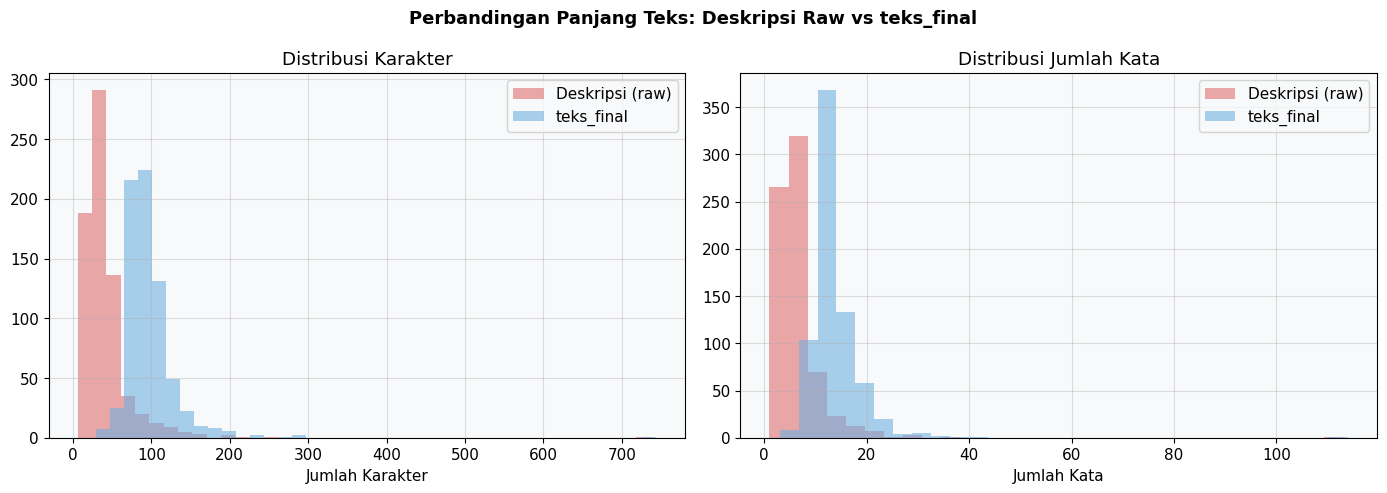

✔ Plot disimpan: 04_perbandingan_panjang_teks.png


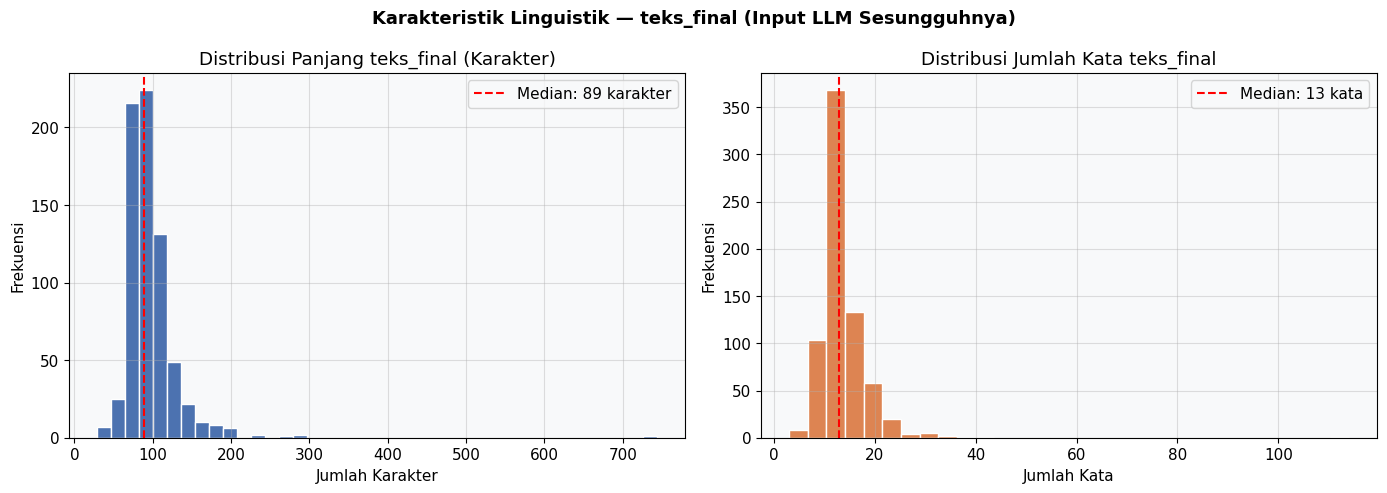

✔ Plot disimpan: 04b_distribusi_teks_final.png


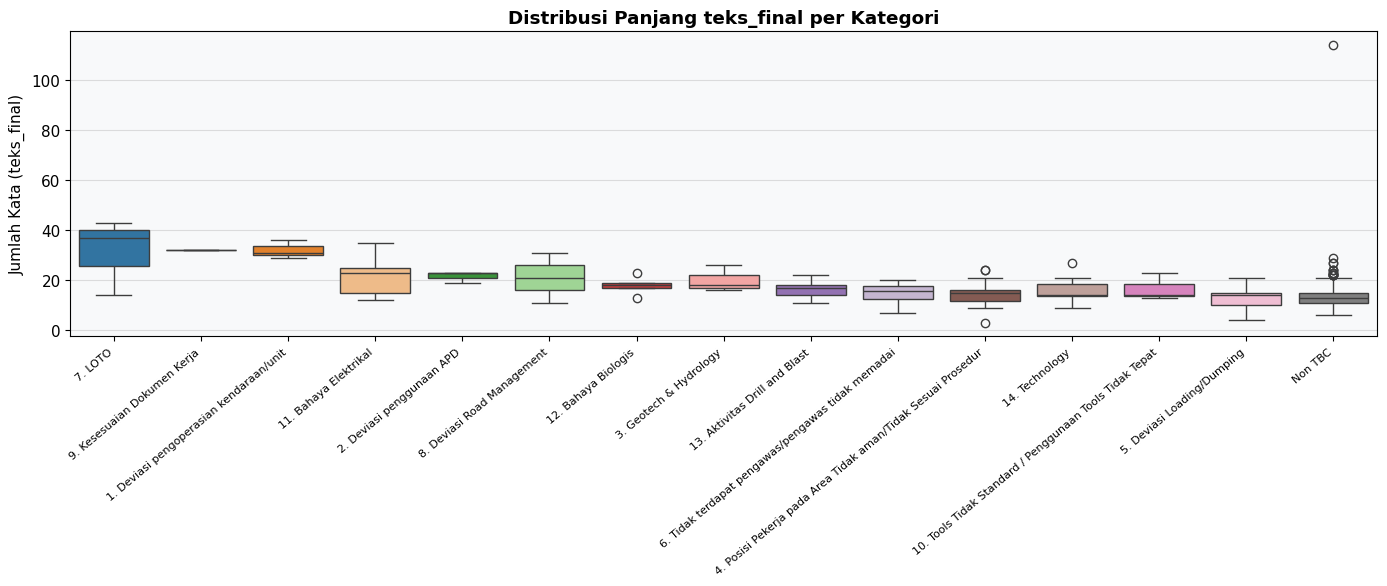

✔ Plot disimpan: 04c_boxplot_panjang_per_kelas.png


In [6]:
# =============================================================================
# TAHAP 4: PREPROCESSING FINAL
# =============================================================================
print("TAHAP 4: PREPROCESSING FINAL")

print("""
Ruang lingkup:
  ✔ Input          : Deskripsi + merge(Lokasi, Detail Lokasi)
  ✔ Format output  : "[DESKRIPSI]: ... [LOKASI]: ..."
  ✔ Hapus          : ID numerik tasklist di awal Deskripsi (6-9 digit)
  ✔ Pertahankan    : Kode site prefix (B8), (PAMA), (BC), dll.
  ✔ Normalisasi    : whitespace stripping, hapus newline/tab
  ✗ Dikecualikan   : Ketidaksesuaian, Sub Ketidaksesuaian (label leakage)
  ✗ TIDAK dilakukan: stopword removal, stemming, case folding
""")
 
 
# ── Fungsi preprocessing ──
 
def safe_str(val) -> str:
    """Konversi aman ke string; NaN → string kosong."""
    if pd.isna(val):
        return ""
    return str(val).strip()
 
 
def strip_leading_id(text: str) -> str:
    """
    Hapus ID numerik tasklist di awal teks (6-9 digit).
    Contoh: "8240459 lampu kerja..." → "lampu kerja..."
    ID ini adalah artifact sistem, bukan konten hazard.
    """
    return re.sub(r"^\d{6,9}\s*", "", text).strip()
 
 
def normalize_whitespace(text: str) -> str:
    """Ganti newline/tab → spasi; hapus spasi berlebih. Tidak menghapus karakter lain."""
    text = re.sub(r"[\n\t\r]+", " ", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()
 
 
def merge_location(lokasi: str, detail: str) -> str:
    """
    Gabungkan Lokasi dan Detail Lokasi.
    - Kode site prefix DIPERTAHANKAN (informasi konteks, bukan noise).
    - Duplikasi dihindari: jika detail sudah terkandung di lokasi, tidak digabung.
    """
    lok = safe_str(lokasi)
    det = safe_str(detail)
 
    if not det:
        return lok
    if not lok:
        return det
    if det.lower() in lok.lower():
        return lok
    if lok.lower() in det.lower():
        return det
    return f"{lok}, {det}"
 
 
def build_teks_final(deskripsi: str, lokasi_merged: str) -> str:
    """
    Bangun teks final dengan separator semantik yang ramah LLM.
    Format: [DESKRIPSI]: <isi> [LOKASI]: <lokasi>
    Jika lokasi kosong: [DESKRIPSI]: <isi>
    """
    desc = normalize_whitespace(safe_str(deskripsi))
    desc = strip_leading_id(desc)
    if not desc:
        desc = "[tidak ada deskripsi]"
 
    if lokasi_merged:
        return f"[DESKRIPSI]: {desc} [LOKASI]: {lokasi_merged}"
    return f"[DESKRIPSI]: {desc}"
 
 
# ── Terapkan preprocessing ──
print("Membangun lokasi_merged...")
df[COL_MERGED] = df.apply(
    lambda row: merge_location(row[COL_LOC], row[COL_LOC_DET]),
    axis=1
)
 
print("Membangun teks_final...")
df[COL_FINAL] = df.apply(
    lambda row: build_teks_final(row[COL_DESC], row[COL_MERGED]),
    axis=1
)
 
# Drop baris dengan teks_final terlalu pendek (≤ 3 karakter setelah strip)
before_drop = len(df)
df = df[df[COL_FINAL].str.strip().str.len() > 3].reset_index(drop=True)
if len(df) < before_drop:
    print(f"⚠  Drop teks terlalu pendek: {before_drop} → {len(df)} baris")
else:
    print(f"✔  Tidak ada teks terlalu pendek (semua > 3 karakter)")
 
# Hitung statistik teks_final
n_char_desc  = df[COL_DESC].astype(str).str.len()
n_word_desc  = df[COL_DESC].astype(str).str.split().str.len()
df["n_char_final"] = df[COL_FINAL].str.len()
df["n_word_final"] = df[COL_FINAL].str.split().str.len()
 
# Reduksi karakter & kata vs deskripsi raw (tanpa ID numerik stripped)
char_reduction = ((n_char_desc - df["n_char_final"]) / n_char_desc.replace(0, np.nan) * 100).mean()
word_reduction = ((n_word_desc - df["n_word_final"]) / n_word_desc.replace(0, np.nan) * 100).mean()
 
print(f"\n✔ Preprocessing selesai untuk {len(df)} baris")
print(f"\n  Statistik teks_final:")
print(f"    Karakter : min={df['n_char_final'].min()}, "
      f"median={df['n_char_final'].median():.0f}, "
      f"mean={df['n_char_final'].mean():.1f}, "
      f"max={df['n_char_final'].max()}")
print(f"    Kata     : min={df['n_word_final'].min()}, "
      f"median={df['n_word_final'].median():.0f}, "
      f"mean={df['n_word_final'].mean():.1f}, "
      f"max={df['n_word_final'].max()}")
print(f"\n  Perubahan vs Deskripsi raw:")
print(f"    Rata-rata Δ karakter : {char_reduction:+.1f}%  (+ = lebih panjang karena [LOKASI])")
print(f"    Rata-rata Δ kata     : {word_reduction:+.1f}%")
 
print("\n── Contoh SEBELUM vs SESUDAH (random sample 3 baris) ──")
sample_idx = df.sample(min(3, len(df)), random_state=42).index
for i, idx in enumerate(sample_idx, 1):
    desc_raw  = str(df.loc[idx, COL_DESC])
    teks_out  = str(df.loc[idx, COL_FINAL])
    print(f"\n  [Contoh {i}]  LABEL: {df.loc[idx, COL_LABEL]}")
    print(f"  SEBELUM : {desc_raw[:200]}{'...' if len(desc_raw) > 200 else ''}")
    print(f"  SESUDAH : {teks_out[:200]}{'...' if len(teks_out) > 200 else ''}")
 
# Visualisasi perbandingan panjang teks: raw deskripsi vs teks_final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Perbandingan Panjang Teks: Deskripsi Raw vs teks_final",
             fontsize=13, fontweight="bold")
axes[0].hist(n_char_desc, bins=40, alpha=0.6, label="Deskripsi (raw)", color="#E07070")
axes[0].hist(df["n_char_final"], bins=40, alpha=0.6, label="teks_final", color="#70B0E0")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_title("Distribusi Karakter")
axes[0].legend()
axes[1].hist(n_word_desc, bins=30, alpha=0.6, label="Deskripsi (raw)", color="#E07070")
axes[1].hist(df["n_word_final"], bins=30, alpha=0.6, label="teks_final", color="#70B0E0")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_title("Distribusi Jumlah Kata")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_perbandingan_panjang_teks.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 04_perbandingan_panjang_teks.png")
 
# ── Distribusi panjang teks_final per kelas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Karakteristik Linguistik — teks_final (Input LLM Sesungguhnya)",
             fontsize=13, fontweight="bold")
axes[0].hist(df["n_char_final"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["n_char_final"].median(), color="red", linestyle="--",
                label=f"Median: {df['n_char_final'].median():.0f} karakter")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Panjang teks_final (Karakter)")
axes[0].legend()
axes[1].hist(df["n_word_final"], bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(df["n_word_final"].median(), color="red", linestyle="--",
                label=f"Median: {df['n_word_final'].median():.0f} kata")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title("Distribusi Jumlah Kata teks_final")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04b_distribusi_teks_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 04b_distribusi_teks_final.png")
 
# ── Boxplot panjang teks per kelas ──
order_kelas = (df.groupby(COL_LABEL)["n_word_final"]
                 .median()
                 .sort_values(ascending=False)
                 .index.tolist())
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x=COL_LABEL, y="n_word_final",
            order=order_kelas, palette="tab20", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
ax.set_xlabel("")
ax.set_ylabel("Jumlah Kata (teks_final)")
ax.set_title("Distribusi Panjang teks_final per Kategori", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04c_boxplot_panjang_per_kelas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 04c_boxplot_panjang_per_kelas.png")

In [7]:
# =============================================================================
# TAHAP 5: QA — VERIFIKASI HASIL PREPROCESSING
# =============================================================================
print("TAHAP 5: QA — VERIFIKASI HASIL PREPROCESSING")
 
teks_series = df[COL_FINAL].astype(str)
site_pattern = re.compile(r"\([A-Za-z0-9\s]+\)")
 
n_loc_empty   = (df[COL_MERGED].isnull() | (df[COL_MERGED].str.strip() == "")).sum()
n_id_leak     = teks_series.str.match(r"^\[DESKRIPSI\]: \d{6,9}").sum()  # ID masih tersisa
n_site_present= teks_series.str.contains(site_pattern, regex=True, na=False).sum()
n_desc_tag    = teks_series.str.contains(r"\[DESKRIPSI\]", regex=True, na=False).sum()
n_loc_tag     = teks_series.str.contains(r"\[LOKASI\]", regex=True, na=False).sum()
n_empty_final = (teks_series.str.strip() == "").sum()
 
print(f"\n  {'CHECK':<55} {'HASIL':>6}  STATUS")
print(f"  {'─'*55} {'─'*6}  {'─'*20}")
print(f"  {'Baris teks_final kosong':<55} {n_empty_final:>6}  "
      f"{'✔ BERSIH' if n_empty_final == 0 else '✗ PERLU CEK'}")
print(f"  {'ID numerik tersisa di awal teks_final':<55} {n_id_leak:>6}  "
      f"{'✔ BERSIH' if n_id_leak == 0 else '✗ PERLU CEK'}")
print(f"  {'Kode site (XX) tetap ada':<55} {n_site_present:>6}  "
      f"{'✔ TERJAGA' if n_site_present > 0 else '✗ HILANG — PERLU CEK'}")
print(f"  {'Baris dengan tag [DESKRIPSI]':<55} {n_desc_tag:>6}  "
      f"{'✔ LENGKAP' if n_desc_tag == len(df) else '✗ ADA YANG KOSONG'}")
print(f"  {'Baris dengan tag [LOKASI]':<55} {n_loc_tag:>6}  "
      f"(✔ NORMAL — {n_loc_empty} baris tanpa lokasi)" if n_loc_tag == len(df) - n_loc_empty
      else f"  {'Baris dengan tag [LOKASI]':<55} {n_loc_tag:>6}  ✗ PERLU CEK")
 
print(f"\n── Sampel 5 baris acak (teks_final + label) ──\n")
sample_qa = df.sample(min(5, len(df)), random_state=42)
for i, (_, row) in enumerate(sample_qa.iterrows(), 1):
    teks = str(row[COL_FINAL])
    print(f"  [{i}] LABEL: {row[COL_LABEL]}")
    print(f"      TEKS : {teks[:200]}{'...' if len(teks) > 200 else ''}")
    print()
 
# Verifikasi jargon teknis tetap aman
print("\n── Verifikasi Jargon Teknis (dari teks_final) ──")
jargon_list = ["APD", "LOTO", "K3", "SOP", "DMS", "TBC", "KDC"]
for jargon in jargon_list:
    n_count = teks_series.str.contains(jargon, case=False, na=False).sum()
    if n_count == 0:
        print(f"  {jargon:<10}: — (tidak ada di data)")
    else:
        print(f"  {jargon:<10}: {n_count} baris  ✔")

TAHAP 5: QA — VERIFIKASI HASIL PREPROCESSING

  CHECK                                                    HASIL  STATUS
  ─────────────────────────────────────────────────────── ──────  ────────────────────
  Baris teks_final kosong                                      0  ✔ BERSIH
  ID numerik tersisa di awal teks_final                        0  ✔ BERSIH
  Kode site (XX) tetap ada                                   229  ✔ TERJAGA
  Baris dengan tag [DESKRIPSI]                               704  ✔ LENGKAP
  Baris dengan tag [LOKASI]                                  672  (✔ NORMAL — 32 baris tanpa lokasi)

── Sampel 5 baris acak (teks_final + label) ──

  [1] LABEL: Non TBC
      TEKS : [DESKRIPSI]: Bohlam lampu anjungan luar sebelah kanan mati [LOKASI]: Towing Tug, TB KSA 78

  [2] LABEL: Non TBC
      TEKS : [DESKRIPSI]: Jalan disposal bergelombang [LOKASI]: Pit East 1, Front loading OB

  [3] LABEL: Non TBC
      TEKS : [DESKRIPSI]: Rantai dafra kapal belom di mani [LOKASI]: Towing Tug,

TAHAP 6: EMBEDDING & VISUALISASI t-SNE (SEMANTIC OVERLAP)

Tujuan:
  Membuktikan secara empiris fenomena Semantic Overlap — titik data
  dari kategori berbeda yang bertumpuk di ruang vektor.
  Embedding dilakukan pada 'teks_final' (input LLM yang sesungguhnya).
 
Model: paraphrase-multilingual-MiniLM-L12-v2 (berjalan LOKAL, tidak perlu API key)



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✔ Model dimuat: paraphrase-multilingual-MiniLM-L12-v2

Encoding 704 dokumen...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

✔ Embedding shape: (704, 384)
✔ Total kelas unik: 15

Menjalankan t-SNE (perplexity=30)...
✔ t-SNE selesai. Shape: (704, 2)


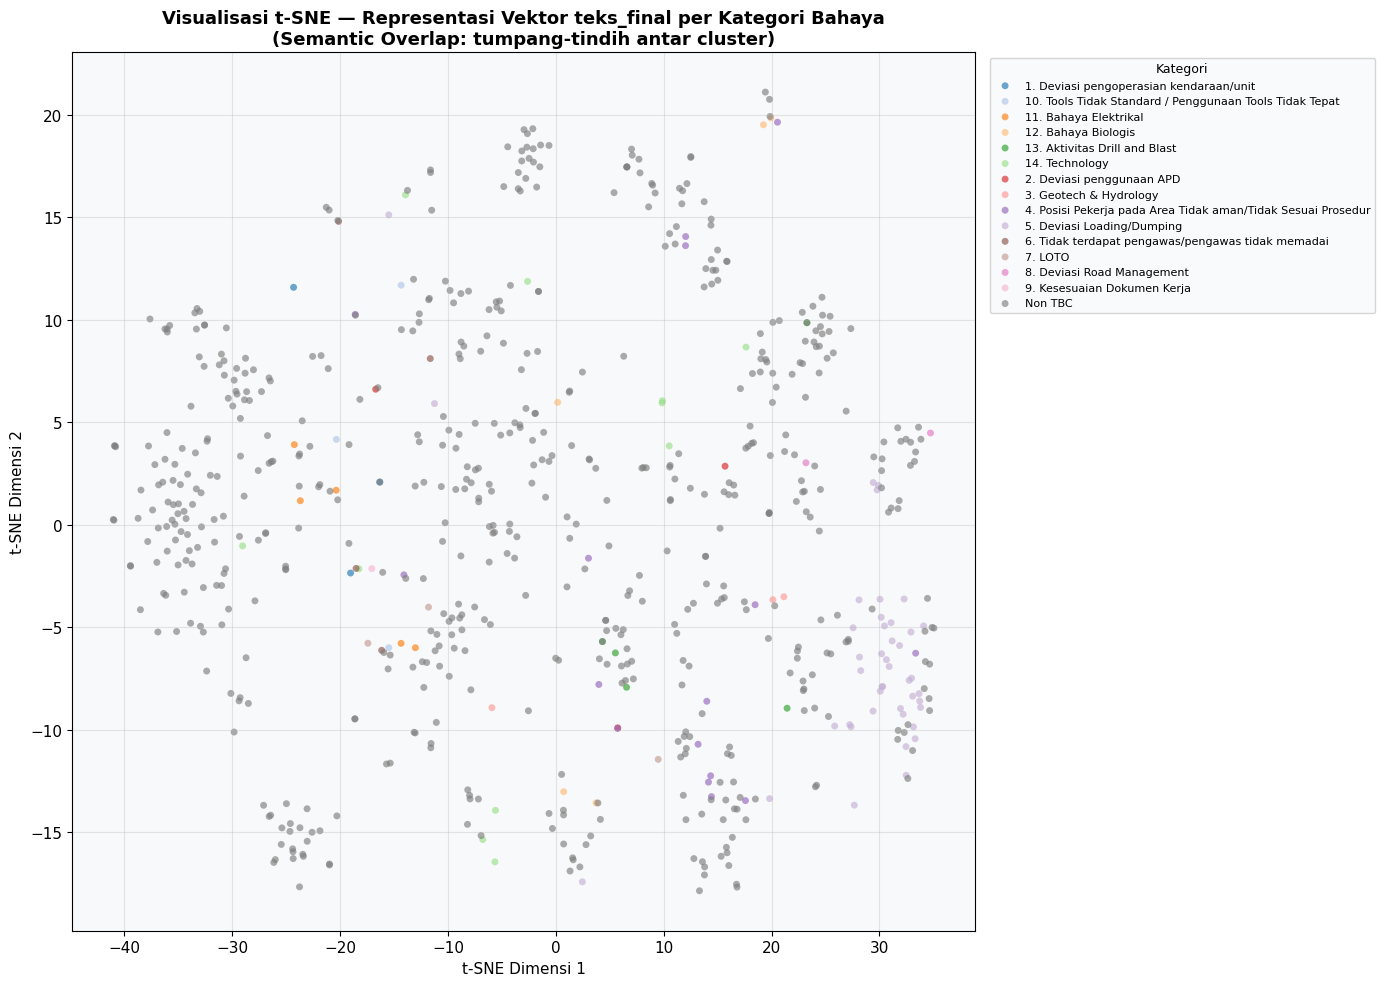

✔ Plot disimpan: 05_tsne_semantic_overlap.png

  Silhouette Score (t-SNE space): -0.4855
  Interpretasi: > 0.50 = terpisah baik | 0.25–0.50 = cukup | < 0.25 = Semantic Overlap tinggi


In [8]:
# =============================================================================
# TAHAP 6: EMBEDDING & VISUALISASI t-SNE (SEMANTIC OVERLAP)
# =============================================================================
print("TAHAP 6: EMBEDDING & VISUALISASI t-SNE (SEMANTIC OVERLAP)")

print(f"""
Tujuan:
  Membuktikan secara empiris fenomena Semantic Overlap — titik data
  dari kategori berbeda yang bertumpuk di ruang vektor.
  Embedding dilakukan pada 'teks_final' (input LLM yang sesungguhnya).
 
Model: {EMBED_MODEL} (berjalan LOKAL, tidak perlu API key)
""")
 
try:
    embedder = SentenceTransformer(EMBED_MODEL)
    print(f"✔ Model dimuat: {EMBED_MODEL}")
except Exception:
    EMBED_MODEL = "all-MiniLM-L6-v2"
    print(f"⚠ Gagal memuat model utama, pakai alternatif: {EMBED_MODEL}")
    embedder = SentenceTransformer(EMBED_MODEL)
 
texts_for_embedding = df[COL_FINAL].fillna("").astype(str).tolist()
texts_for_embedding = [t if t.strip() else " " for t in texts_for_embedding]
 
print(f"\nEncoding {len(texts_for_embedding)} dokumen...")
embeddings = embedder.encode(
    texts_for_embedding,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f"✔ Embedding shape: {embeddings.shape}")
 
le        = LabelEncoder()
label_ids = le.fit_transform(df[COL_LABEL])
print(f"✔ Total kelas unik: {len(le.classes_)}")
 
# t-SNE — gunakan max_iter (kompatibel scikit-learn >= 1.2)
perplexity_val = min(30, len(df) - 1)
print(f"\nMenjalankan t-SNE (perplexity={perplexity_val})...")
 
try:
    tsne = TSNE(n_components=2, perplexity=perplexity_val, max_iter=1000,
                random_state=RANDOM_SEED, metric="cosine", init="pca",
                learning_rate="auto")
    tsne_result = tsne.fit_transform(embeddings)
except TypeError:
    # Fallback untuk scikit-learn < 1.2
    tsne = TSNE(n_components=2, perplexity=perplexity_val, n_iter=1000,
                random_state=RANDOM_SEED, metric="cosine", init="pca",
                learning_rate="auto")
    tsne_result = tsne.fit_transform(embeddings)
 
print(f"✔ t-SNE selesai. Shape: {tsne_result.shape}")
 
palette = sns.color_palette("tab20", len(le.classes_))
fig, ax = plt.subplots(figsize=(14, 10))
for i, cls in enumerate(le.classes_):
    mask = label_ids == i
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               c=[palette[i]], label=cls, alpha=0.65, s=25, edgecolors="none")
ax.set_title(
    "Visualisasi t-SNE — Representasi Vektor teks_final per Kategori Bahaya\n"
    "(Semantic Overlap: tumpang-tindih antar cluster)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("t-SNE Dimensi 1")
ax.set_ylabel("t-SNE Dimensi 2")
ax.legend(title="Kategori", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, title_fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_tsne_semantic_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 05_tsne_semantic_overlap.png")
 
# Silhouette Score
sample_s  = min(500, len(df) - 1)
sil_score = -1.0
if len(le.classes_) > 1 and len(df) > 2:
    sil_score = silhouette_score(tsne_result, label_ids,
                                 sample_size=sample_s, random_state=RANDOM_SEED)
    print(f"\n  Silhouette Score (t-SNE space): {sil_score:.4f}")
    print("  Interpretasi: > 0.50 = terpisah baik | 0.25–0.50 = cukup | < 0.25 = Semantic Overlap tinggi")
else:
    print("\n⚠ Silhouette Score tidak dapat dihitung.")

TAHAP 7: DEDUPLIKASI & STRATIFIED SPLIT
⚠  Duplikat tasklist_id dihapus: 2 baris (704 → 702)

⚠  Kelas dengan < 2 sampel (masuk KB semua):
    • '9. Kesesuaian Dokumen Kerja' (1 sampel)

  Ukuran split:
  Knowledge Base :  631 data  (89.9%)
  Test Set       :   71 data  (10.1%)
  Total          :  702 data

  KATEGORI                                                      KB  TEST
  ────────────────────────────────────────────────────────── ───── ─────
  1. Deviasi pengoperasian kendaraan/unit                        3     0
  10. Tools Tidak Standard / Penggunaan Tools Tidak Tepat        3     0
  11. Bahaya Elektrikal                                          4     1
  12. Bahaya Biologis                                            4     1
  13. Aktivitas Drill and Blast                                  3     0
  14. Technology                                                10     1
  2. Deviasi penggunaan APD                                      3     0
  3. Geotech & Hydrology          

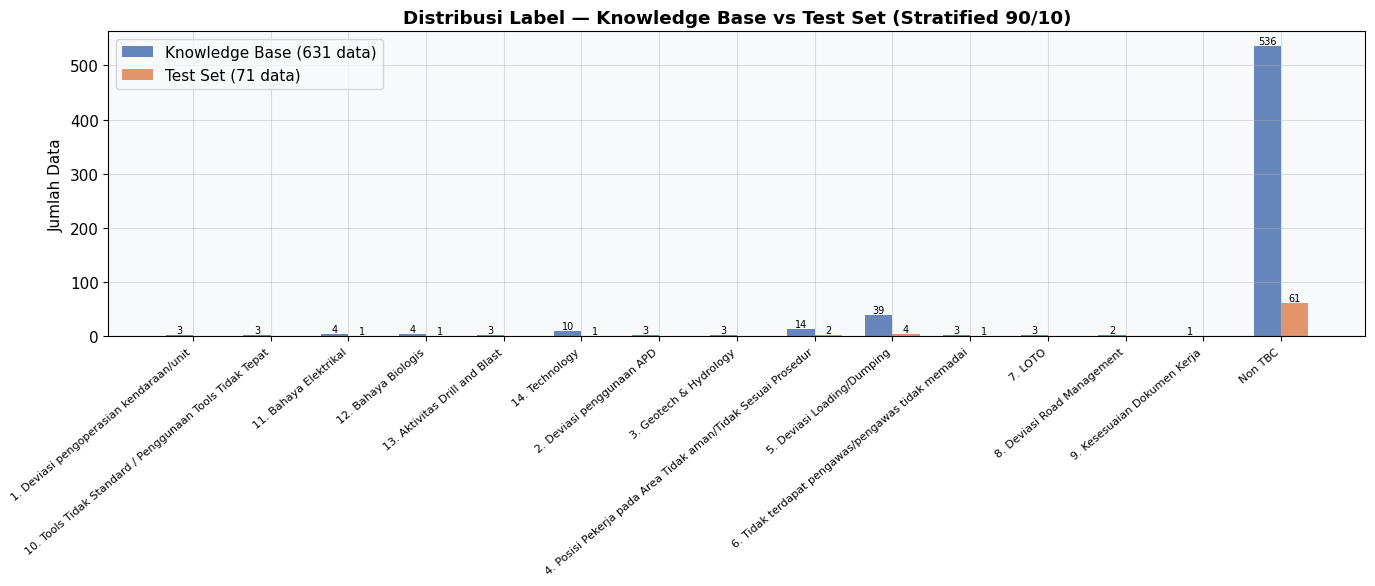

✔ Plot disimpan: 06_distribusi_split.png


In [9]:
# =============================================================================
# TAHAP 7: DEDUPLIKASI & STRATIFIED SPLIT (KB 90% / TEST 10%)
# =============================================================================
print("TAHAP 7: DEDUPLIKASI & STRATIFIED SPLIT")
 
# ── 7a. Deduplikasi berdasarkan tasklist_id ──
n_before = len(df)
df = df.drop_duplicates(subset=[COL_ID], keep="first").reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"⚠  Duplikat tasklist_id dihapus: {n_removed} baris ({n_before} → {len(df)})")
else:
    print(f"✔  Tidak ada duplikat tasklist_id")
 
n_after_dedup = len(df)
 
# ── 7b. Identifikasi kelas kecil (< 2 sampel → masuk KB semua) ──
vc_count  = df[COL_LABEL].value_counts()
too_small = vc_count[vc_count < 2].index.tolist()
can_split = vc_count[vc_count >= 2].index.tolist()
 
df_small      = df[df[COL_LABEL].isin(too_small)].copy()
df_splittable = df[df[COL_LABEL].isin(can_split)].copy()
 
if too_small:
    print(f"\n⚠  Kelas dengan < 2 sampel (masuk KB semua):")
    for lbl in too_small:
        print(f"    • '{lbl}' ({vc_count[lbl]} sampel)")
else:
    print(f"✔  Semua kelas memiliki ≥ 2 sampel")
 
# ── 7c. Stratified split ──
df_kb_main, df_test = train_test_split(
    df_splittable,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = df_splittable[COL_LABEL],
)
 
df_kb = (pd.concat([df_kb_main, df_small], ignore_index=True)
           .sample(frac=1, random_state=RANDOM_SEED)
           .reset_index(drop=True))
df_test = df_test.reset_index(drop=True)
 
print(f"\n  Ukuran split:")
print(f"  Knowledge Base : {len(df_kb):>4} data  ({len(df_kb)/n_after_dedup*100:.1f}%)")
print(f"  Test Set       : {len(df_test):>4} data  ({len(df_test)/n_after_dedup*100:.1f}%)")
print(f"  Total          : {len(df_kb)+len(df_test):>4} data")
 
# Tabel distribusi per split
all_labels = sorted(df[COL_LABEL].unique())
print(f"\n  {'KATEGORI':<58} {'KB':>5} {'TEST':>5}")
print(f"  {'─'*58} {'─'*5} {'─'*5}")
for lbl in all_labels:
    n_kb   = (df_kb[COL_LABEL]   == lbl).sum()
    n_test = (df_test[COL_LABEL] == lbl).sum()
    note   = " ← hanya KB" if lbl in too_small else ""
    print(f"  {lbl:<58} {n_kb:>5} {n_test:>5}{note}")
print(f"  {'─'*58} {'─'*5} {'─'*5}")
print(f"  {'TOTAL':<58} {len(df_kb):>5} {len(df_test):>5}")
 
# Verifikasi tidak ada overlap
overlap = set(df_kb[COL_ID].astype(str)) & set(df_test[COL_ID].astype(str))
print(f"\n  ✔ Overlap KB ∩ Test : {len(overlap)} record (target: 0)")
 
# Visualisasi distribusi split
fig, ax = plt.subplots(figsize=(14, 6))
x    = np.arange(len(all_labels))
w    = 0.35
n_kb_vals = [(df_kb[COL_LABEL]   == l).sum() for l in all_labels]
n_ts_vals = [(df_test[COL_LABEL] == l).sum() for l in all_labels]
 
b1 = ax.bar(x - w/2, n_kb_vals, w, label=f"Knowledge Base ({len(df_kb)} data)",
            color="#4C72B0", alpha=0.85)
b2 = ax.bar(x + w/2, n_ts_vals, w, label=f"Test Set ({len(df_test)} data)",
            color="#DD8452", alpha=0.85)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                str(int(h)), ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Jumlah Data")
ax.set_title("Distribusi Label — Knowledge Base vs Test Set (Stratified 90/10)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_distribusi_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot disimpan: 06_distribusi_split.png")

In [10]:
# =============================================================================
# TAHAP 8: EKSPOR OUTPUT FINAL
# =============================================================================
print("TAHAP 8: EKSPOR OUTPUT FINAL")
 
# Kolom yang diekspor (konsisten untuk semua file output)
COLS_OUT = [COL_ID, COL_LABEL, COL_DESC, COL_LOC, COL_LOC_DET,
            COL_MERGED, COL_FINAL]
COLS_RENAME = {
    COL_ID     : "tasklist_id",
    COL_LABEL  : "label",
    COL_DESC   : "deskripsi",
    COL_LOC    : "lokasi",
    COL_LOC_DET: "detail_lokasi",
    COL_MERGED : "lokasi_merged",
    COL_FINAL  : "teks_final",
}
 
def export_df(dataframe, name_stem, n_after_dedup):
    """Helper: rename → simpan xlsx + csv → print info."""
    cols_available = [c for c in COLS_OUT if c in dataframe.columns]
    out = dataframe[cols_available].copy().rename(columns=COLS_RENAME)
    out.to_excel(f"{OUTPUT_DIR}/{name_stem}.xlsx", index=False)
    out.to_csv(f"{OUTPUT_DIR}/{name_stem}.csv",   index=False)
    print(f"  ✔ {name_stem:<30} — {len(out)} baris × {len(out.columns)} kolom")
    return out
 
# Dataset penuh (setelah dedup, sebelum split)
export_df(df,      "dataset_final",      n_after_dedup)
# Knowledge Base
export_df(df_kb,   "split_knowledge_base", n_after_dedup)
# Test Set
export_df(df_test, "split_test_set",     n_after_dedup)
 
# Hitung ulang QA tags dari df setelah dedup (untuk ringkasan yang akurat)
teks_series_final = df[COL_FINAL].astype(str)
n_desc_tag_final  = teks_series_final.str.contains(r"\[DESKRIPSI\]", regex=True, na=False).sum()
n_loc_tag_final   = teks_series_final.str.contains(r"\[LOKASI\]",    regex=True, na=False).sum()
n_loc_empty_final = (df[COL_MERGED].str.strip() == "").sum()
 
# =============================================================================
# RINGKASAN AKHIR
# =============================================================================
print(f"""
RINGKASAN PIPELINE EDA & PREPROCESSING
 
  [DATA]
  File sumber              : {FILE_PATH}
  Total data raw           : {n_raw}
  Setelah drop null label  : {n_before}
  Setelah deduplikasi ID   : {n_after_dedup} ({n_removed} duplikat dihapus)
 
  [KELAS]
  Total kelas              : {n_class}
  Imbalance Ratio (IR)     : {ir:.2f}x
  Kelas mayoritas          : {class_counts.idxmax()} ({class_pct.max()}%)
 
  [FORMAT teks_final]
  Template                 : [DESKRIPSI]: ... [LOKASI]: ...
  Baris dengan [DESKRIPSI] : {n_desc_tag_final} / {n_after_dedup}
  Baris dengan [LOKASI]    : {n_loc_tag_final} / {n_after_dedup}  ({n_loc_empty_final} tanpa lokasi)
  Karakter — median        : {df['n_char_final'].median():.0f}
  Kata — median            : {df['n_word_final'].median():.0f}
 
  [SPLIT]
  Knowledge Base           : {len(df_kb)} data ({len(df_kb)/n_after_dedup*100:.1f}%)
  Test Set (FIXED)         : {len(df_test)} data ({len(df_test)/n_after_dedup*100:.1f}%)
  Overlap KB ∩ Test        : {len(overlap)} (target: 0)
 
  [EMBEDDING]
  Model                    : {EMBED_MODEL}
  Silhouette Score (t-SNE) : {sil_score:.4f}
 
  [OUTPUT FILES]
  Plot  : 01_distribusi_kelas.png
          02_distribusi_panjang_teks_eda.png
          03_frekuensi_kata_eda.png
          04_perbandingan_panjang_teks.png
          05_tsne_semantic_overlap.png
          06_distribusi_split.png
  Data  : dataset_final.xlsx / .csv          → full dataset (setelah dedup)
          split_knowledge_base.xlsx / .csv   → diindeks ke ChromaDB (RAG)
          split_test_set.xlsx / .csv         → FIXED, dipakai semua skenario
 
  [KOLOM OUTPUT — semua file]
  tasklist_id | label | deskripsi | lokasi | detail_lokasi |
  lokasi_merged | teks_final
 
✅  Pipeline selesai. split_knowledge_base → ChromaDB. split_test_set → evaluasi.
""")

TAHAP 8: EKSPOR OUTPUT FINAL
  ✔ dataset_final                  — 702 baris × 7 kolom
  ✔ split_knowledge_base           — 631 baris × 7 kolom
  ✔ split_test_set                 — 71 baris × 7 kolom

RINGKASAN PIPELINE EDA & PREPROCESSING
 
  [DATA]
  File sumber              : Dataset_Thesis4.xlsx
  Total data raw           : 704
  Setelah drop null label  : 704
  Setelah deduplikasi ID   : 702 (2 duplikat dihapus)
 
  [KELAS]
  Total kelas              : 15
  Imbalance Ratio (IR)     : 597.00x
  Kelas mayoritas          : Non TBC (84.8%)
 
  [FORMAT teks_final]
  Template                 : [DESKRIPSI]: ... [LOKASI]: ...
  Baris dengan [DESKRIPSI] : 702 / 702
  Baris dengan [LOKASI]    : 670 / 702  (32 tanpa lokasi)
  Karakter — median        : 89
  Kata — median            : 13
 
  [SPLIT]
  Knowledge Base           : 631 data (89.9%)
  Test Set (FIXED)         : 71 data (10.1%)
  Overlap KB ∩ Test        : 0 (target: 0)
 
  [EMBEDDING]
  Model                    : paraphrase-multili